# Bibliotecas

In [1]:
# Bibliotecas gerais
import os
import time
from datetime import datetime
from getpass import getpass
from IPython.display import display
import html
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Bibliotecas de dados
import pandas as pd
pd.set_option('display.precision', 10)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Biblioteca para armazenar dados no banco de dados
from sqlalchemy import create_engine

# Configurações banco de dados

In [2]:
# Tenta recuperar a conexão com o banco, se definido antes
db_engine = globals().get("db_engine", None)

# Configuração do MySQL 
if not db_engine:
    # Host e Database
    host = "localhost"
    database = "MF"
    
    # Solicita usuário e senha de forma segura
    user = input("Digite seu usuário MySQL: ")
    password = getpass.getpass("Digite sua senha MySQL (não será exibida): ")
    
    # Cria a engine SQLAlchemy
    db_engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{database}")

    print("Configuração do Banco de Dados criada com Sucesso!!!")

else:
    print("Configuração já existe. Usando configuração já existente!!!")

Digite seu usuário MySQL:  tomida
Digite sua senha MySQL (não será exibida):  ········


Configuração do Banco de Dados criada com Sucesso!!!


# Configurações gerais

In [3]:
# ==========================================================
# ETAPA 1 - CONFIGURAÇÃO INICIAL DO PROJETO
# Preparação da base + estrutura de pastas + funções auxiliares
# ==========================================================

# =========================
# CONFIGURAÇÕES GERAIS
# =========================
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# =========================
# ESTRUTURA DE PASTAS
# =========================
PASTA_RESULTADOS = Path("resultados")
PASTA_GRAFICOS = PASTA_RESULTADOS / "graficos"
PASTA_TABELAS = PASTA_RESULTADOS / "tabelas"

PASTA_RESULTADOS.mkdir(exist_ok=True)
PASTA_GRAFICOS.mkdir(exist_ok=True)
PASTA_TABELAS.mkdir(exist_ok=True)

print("Pastas criadas/verificadas com sucesso:")
print(f" - {PASTA_RESULTADOS}")
print(f" - {PASTA_GRAFICOS}")
print(f" - {PASTA_TABELAS}")

# =========================
# FUNÇÕES AUXILIARES DE SALVAMENTO
# =========================
def salvar_tabela_csv(df, nome_arquivo, index=False, sep=";"):
    """
    Descrição:
        Salva um DataFrame em CSV na pasta de tabelas do projeto.

    Parâmetros:
        df (pandas.DataFrame):
            DataFrame a ser salvo.
        nome_arquivo (str):
            Nome do arquivo CSV.
        index (bool):
            Se True, salva o índice.
        sep (str):
            Separador do CSV.

    Retorno:
        str:
            Caminho final do arquivo salvo.
    """
    caminho = PASTA_TABELAS / nome_arquivo
    df.to_csv(caminho, index=index, sep=sep, encoding="utf-8-sig")
    print(f"Tabela CSV salva em: {caminho}")
    return str(caminho)


def salvar_tabela(df, nome_arquivo, index=False):

    """
    Descrição:
        Salva um DataFrame em HTML na pasta de tabelas do projeto.

    Parâmetros:
        df (pandas.DataFrame):
            DataFrame a ser salvo.
        nome_arquivo (str):
            Nome do arquivo HTML.
        index (bool):
            Se True, salva o índice.

    Retorno:
        str:
            Caminho final do arquivo salvo.
    """
    
    caminho = PASTA_TABELAS / nome_arquivo
    html = df.to_html(index=index, border=0, classes="display nowrap compact", justify="center")
    
    with open(caminho, "w", encoding="utf-8") as f:
        f.write(html)
    
    print(f"Tabela salva em: {caminho}")
    return str(caminho)


def salvar_grafico(nome_arquivo, dpi=150, bbox_inches="tight"):
    """
    Descrição:
        Salva o gráfico atualmente aberto do matplotlib na pasta de gráficos.

    Parâmetros:
        nome_arquivo (str):
            Nome do arquivo PNG.
        dpi (int):
            Resolução do gráfico.
        bbox_inches (str):
            Ajuste de borda do arquivo.

    Retorno:
        str:
            Caminho final do arquivo salvo.
    """
    caminho = PASTA_GRAFICOS / nome_arquivo
    plt.savefig(caminho, dpi=dpi, bbox_inches=bbox_inches)
    print(f"Gráfico salvo em: {caminho}")
    return str(caminho)

# =========================
# FUNÇÃO PARA PREPARAR A BASE
# =========================
def preparar_base(df, col_ticker="ticker", col_data="data", col_preco="close", col_volume_fin="volume_fin"):
    """
    Descrição:
        Faz a preparação inicial da base histórica de ações para o projeto do efeito janeiro.

    Parâmetros:
        df (pandas.DataFrame):
            Base original contendo ao menos ticker, data, preço e volume financeiro.
        col_ticker (str):
            Nome da coluna de ticker.
        col_data (str):
            Nome da coluna de data.
        col_preco (str):
            Nome da coluna de preço de fechamento.
        col_volume_fin (str):
            Nome da coluna de volume financeiro.

    Processo:
        1. Copia o DataFrame para evitar alteração da base original.
        2. Padroniza nomes principais.
        3. Converte data para datetime.
        4. Remove linhas sem ticker, data ou preço.
        5. Ordena por ticker e data.
        6. Cria colunas auxiliares de ano, mês e ano_mes.

    Retorno:
        pandas.DataFrame:
            Base preparada para as próximas etapas do projeto.
    """

    print("=" * 70)
    print("INICIANDO PREPARAÇÃO DA BASE")
    print("=" * 70)

    df = df.copy()

    # -----------------------------------------
    # Padroniza colunas principais para nomes fixos
    # -----------------------------------------
    rename_map = {
        col_ticker: "ticker",
        col_data: "data",
        col_preco: "preco",
        col_volume_fin: "volume_fin"
    }
    df = df.rename(columns=rename_map)

    # -----------------------------------------
    # Converte data
    # -----------------------------------------
    df["data"] = pd.to_datetime(df["data"], errors="coerce")

    # -----------------------------------------
    # Remove linhas essenciais faltantes
    # -----------------------------------------
    antes = len(df)
    df = df.dropna(subset=["ticker", "data", "preco"])
    depois = len(df)

    print(f"Linhas antes da limpeza: {antes:,}")
    print(f"Linhas após remover nulos essenciais: {depois:,}")
    print(f"Linhas removidas: {antes - depois:,}")

    # -----------------------------------------
    # Garante ticker como string padronizada
    # -----------------------------------------
    df["ticker"] = df["ticker"].astype(str).str.upper().str.strip()

    # -----------------------------------------
    # Ordena por ticker e data
    # -----------------------------------------
    df = df.sort_values(["ticker", "data"]).reset_index(drop=True)

    # -----------------------------------------
    # Colunas auxiliares de tempo
    # -----------------------------------------
    df["ano"] = df["data"].dt.year
    df["mes"] = df["data"].dt.month
    df["ano_mes"] = df["data"].dt.to_period("M").astype(str)

    # -----------------------------------------
    # Diagnóstico rápido
    # -----------------------------------------
    print("-" * 70)
    print("Resumo da base preparada:")
    print(f"Período: {df['data'].min().date()} até {df['data'].max().date()}")
    print(f"Quantidade de tickers: {df['ticker'].nunique():,}")
    print(f"Quantidade de linhas: {len(df):,}")

    colunas_mostrar = [c for c in ["ticker", "data", "preco", "volume_fin", "ano", "mes", "ano_mes"] if c in df.columns]
    display(df[colunas_mostrar].head())

    print("=" * 70)
    print("BASE PREPARADA COM SUCESSO")
    print("=" * 70)

    return df

Pastas criadas/verificadas com sucesso:
 - resultados
 - resultados\graficos
 - resultados\tabelas


# Base de cotações das ações

In [4]:
db_engine = globals().get("db_engine", None)

if not db_engine:
    host = "localhost"
    database = "MF"

    user = input("Digite seu usuário MySQL: ")
    password = getpass.getpass("Digite sua senha MySQL (não será exibida): ")

    db_engine = create_engine(
        f"mysql+mysqlconnector://{user}:{password}@{host}/{database}"
    )


query = f"""
SELECT 
    ticker, 
    data,
    close,
    close_adj,
    volume_fin
FROM cot_hist_consolidado 
"""

print("Lendo dados do banco...")

df_base = pd.read_sql(query, con=db_engine)

Lendo dados do banco...


In [5]:
df_base.shape

(1262516, 5)

In [6]:
df_base

,ticker,data,close,close_adj,volume_fin
0,AALR3,2016-10-28,19.200000,18.830400,"122,334,647.000000"
1,AALR3,2016-10-31,18.060000,17.715700,"45,857,231.000000"
2,AALR3,2016-11-01,17.900000,17.557900,"17,676,981.000000"
3,AALR3,2016-11-03,17.990000,17.646600,"11,132,994.000000"
4,AALR3,2016-11-04,17.750000,17.409900,"6,955,112.000000"
...,...,...,...,...,...
1262511,ZAMP3,2025-11-26,3.500000,3.500000,"166,427.000000"
1262512,ZAMP3,2025-11-27,3.510000,3.510000,"187,665.000000"
1262513,ZAMP3,2025-11-28,3.500000,3.500000,"270,254.000000"
1262514,ZAMP3,2025-12-01,3.500000,3.500000,"95,175.000000"


In [7]:
# Preparar base
df_base_preparada = preparar_base(
     df=df_base,
     col_ticker="ticker",
     col_data="data",
     col_preco="close_adj",  
     col_volume_fin="volume_fin"
 )

# Salva tabela
salvar_tabela(df_base_preparada.head(100), "preview_base_preparada.html", index=False)

INICIANDO PREPARAÇÃO DA BASE
Linhas antes da limpeza: 1,262,516
Linhas após remover nulos essenciais: 1,262,516
Linhas removidas: 0
----------------------------------------------------------------------
Resumo da base preparada:
Período: 2010-01-04 até 2025-12-30
Quantidade de tickers: 698
Quantidade de linhas: 1,262,516


,ticker,data,preco,volume_fin,ano,mes,ano_mes
0,AALR3,2016-10-28,18.830400,"122,334,647.000000",2016,10,2016-10
1,AALR3,2016-10-31,17.715700,"45,857,231.000000",2016,10,2016-10
2,AALR3,2016-11-01,17.557900,"17,676,981.000000",2016,11,2016-11
3,AALR3,2016-11-03,17.646600,"11,132,994.000000",2016,11,2016-11
4,AALR3,2016-11-04,17.409900,"6,955,112.000000",2016,11,2016-11


BASE PREPARADA COM SUCESSO
Tabela salva em: resultados\tabelas\preview_base_preparada.html


'resultados\\tabelas\\preview_base_preparada.html'

# Universo Elegível + Liquidez de Novembro

In [8]:
# ==========================================================
# ETAPA 2 - UNIVERSO ELEGÍVEL + LIQUIDEZ DE NOVEMBRO
# ==========================================================

print("=" * 70)
print("INICIANDO CONSTRUÇÃO DO UNIVERSO ELEGÍVEL")
print("=" * 70)

df = df_base_preparada.copy()

# ----------------------------------------------------------
# 1) LIQUIDEZ MÉDIA DE NOVEMBRO
# ----------------------------------------------------------
print("Calculando liquidez média de novembro...")

df_nov = df[df["mes"] == 11].copy()

liq_nov = (
    df_nov
    .groupby(["ticker", "ano"], as_index=False)
    .agg(liquidez_novembro=("volume_fin", "mean"))
)

print(f"Total de registros de liquidez: {len(liq_nov):,}")

# ----------------------------------------------------------
# 2) DEFINIR DATAS DE ENTRADA E SAÍDA
# ----------------------------------------------------------
print("Definindo datas de entrada e saída por ano...")

datas_entrada = []
datas_saida = []

anos = sorted(df["ano"].unique())

for ano in anos:

    # -----------------------------
    # ENTRADA -> após 15/dez do ano anterior
    # -----------------------------
    df_entrada = df[
        (df["data"] >= pd.Timestamp(f"{ano-1}-12-15")) &
        (df["data"] <= pd.Timestamp(f"{ano-1}-12-31"))
    ]

    if not df_entrada.empty:
        data_entrada = df_entrada["data"].min()
        datas_entrada.append({"ano": ano, "data_entrada": data_entrada})

    # -----------------------------
    # SAÍDA -> último pregão de janeiro
    # -----------------------------
    df_saida = df[
        (df["data"] >= pd.Timestamp(f"{ano}-01-01")) &
        (df["data"] <= pd.Timestamp(f"{ano}-01-31"))
    ]

    if not df_saida.empty:
        data_saida = df_saida["data"].max()
        datas_saida.append({"ano": ano, "data_saida": data_saida})


df_datas_entrada = pd.DataFrame(datas_entrada)
df_datas_saida = pd.DataFrame(datas_saida)

df_datas = df_datas_entrada.merge(df_datas_saida, on="ano", how="inner")

print(f"Total de anos com datas válidas: {len(df_datas):,}")

# ----------------------------------------------------------
# 3) PEGAR PREÇOS NAS DATAS
# ----------------------------------------------------------
print("Extraindo preços de entrada e saída...")

# Merge entrada
df_entrada_precos = df.merge(
    df_datas.rename(columns={"ano": "ano_janela"}),
    left_on="data",
    right_on="data_entrada",
    how="inner"
)

df_entrada_precos = (
    df_entrada_precos[["ticker", "ano_janela", "preco"]]
    .rename(columns={"ano_janela": "ano", "preco": "preco_entrada"})
    .copy()
)


# Merge saída
df_saida_precos = df.merge(
    df_datas.rename(columns={"ano": "ano_janela"}),
    left_on="data",
    right_on="data_saida",
    how="inner"
)

df_saida_precos = (
    df_saida_precos[["ticker", "ano_janela", "preco"]]
    .rename(columns={"ano_janela": "ano", "preco": "preco_saida"})
    .copy()
)

# ----------------------------------------------------------
# 4) MONTAR UNIVERSO ELEGÍVEL
# ----------------------------------------------------------
print("Montando universo elegível...")

df_universo = (
    liq_nov
    .merge(df_entrada_precos, on=["ticker", "ano"], how="inner")
    .merge(df_saida_precos, on=["ticker", "ano"], how="inner")
    .merge(df_datas, on="ano", how="left")
)

print(f"Total de observações elegíveis: {len(df_universo):,}")
print(f"Total de anos: {df_universo['ano'].nunique():,}")
print(f"Total de tickers únicos: {df_universo['ticker'].nunique():,}")

# ----------------------------------------------------------
# 5) DIAGNÓSTICO POR ANO
# ----------------------------------------------------------
print("Gerando tabela de amostra anual...")

tabela_amostra = (
    df_universo
    .groupby("ano")
    .agg(
        n_empresas=("ticker", "nunique"),
        liquidez_media=("liquidez_novembro", "mean")
    )
    .reset_index()
    .sort_values("ano")
)

display(tabela_amostra.head(10))

# ----------------------------------------------------------
# 6) SALVAR RESULTADOS IMPORTANTES
# ----------------------------------------------------------
print("Salvando outputs...")

# Preview da base universo (para debug)
salvar_tabela(df_universo.head(200), "preview_universo_elegivel.html", index=False)

# Tabela importante para o HTML final
salvar_tabela(tabela_amostra, "tabela_amostra_anual.html", index=False)

print("=" * 70)
print("UNIVERSO ELEGÍVEL CONSTRUÍDO COM SUCESSO")
print("=" * 70)

INICIANDO CONSTRUÇÃO DO UNIVERSO ELEGÍVEL
Calculando liquidez média de novembro...
Total de registros de liquidez: 6,355
Definindo datas de entrada e saída por ano...
Total de anos com datas válidas: 15
Extraindo preços de entrada e saída...
Montando universo elegível...
Total de observações elegíveis: 4,328
Total de anos: 15
Total de tickers únicos: 535
Gerando tabela de amostra anual...


,ano,n_empresas,liquidez_media
0,2011,246,"18,689,324.489603"
1,2012,258,"21,316,504.367817"
2,2013,253,"23,715,471.848912"
3,2014,247,"22,342,507.440689"
4,2015,254,"20,163,222.411436"
5,2016,225,"34,106,275.424739"
6,2017,256,"31,123,697.678786"
7,2018,273,"46,732,041.943836"
8,2019,288,"54,599,821.960055"
9,2020,313,"88,097,998.199722"


Salvando outputs...
Tabela salva em: resultados\tabelas\preview_universo_elegivel.html
Tabela salva em: resultados\tabelas\tabela_amostra_anual.html
UNIVERSO ELEGÍVEL CONSTRUÍDO COM SUCESSO


# Classificação + Retornos + Carteiras

In [9]:
# ==========================================================
# ETAPA 3 - CLASSIFICAÇÃO + RETORNOS + CARTEIRAS
# ==========================================================

print("=" * 70)
print("INICIANDO CLASSIFICAÇÃO E CÁLCULO DE RETORNOS")
print("=" * 70)

df = df_universo.copy()

# ----------------------------------------------------------
# 1) CLASSIFICAÇÃO POR LIQUIDEZ (POR ANO)
# ----------------------------------------------------------
print("Classificando small vs large caps...")

def classificar_grupo(df_ano):
    df_ano = df_ano.sort_values("liquidez_novembro")

    n = len(df_ano)
    n_cut = int(n * 0.3)

    df_ano["grupo"] = "middle"

    if n_cut > 0:
        df_ano.iloc[:n_cut, df_ano.columns.get_loc("grupo")] = "small"
        df_ano.iloc[-n_cut:, df_ano.columns.get_loc("grupo")] = "large"

    return df_ano

df = (
    df
    .groupby("ano", group_keys=False)
    .apply(classificar_grupo)
)

print("Classificação concluída.")

# ----------------------------------------------------------
# 2) CALCULAR RETORNO
# ----------------------------------------------------------
print("Calculando retornos...")

df["retorno"] = (df["preco_saida"] / df["preco_entrada"]) - 1

# Remover valores absurdos (proteção)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["retorno"])

print("Retornos calculados.")

# ----------------------------------------------------------
# 3) FILTRAR APENAS SMALL E LARGE
# ----------------------------------------------------------
df_filtrado = df[df["grupo"].isin(["small", "large"])].copy()

print(f"Total após filtro small/large: {len(df_filtrado):,}")

# ----------------------------------------------------------
# 4) CARTEIRAS POR ANO
# ----------------------------------------------------------
print("Calculando carteiras por ano...")

df_carteiras = (
    df_filtrado
    .groupby(["ano", "grupo"])
    .agg(
        retorno_medio=("retorno", "mean"),
        n_empresas=("ticker", "nunique")
    )
    .reset_index()
)

# Pivot para formato final
df_carteiras_pivot = df_carteiras.pivot(index="ano", columns="grupo", values="retorno_medio")
df_qtd = df_carteiras.pivot(index="ano", columns="grupo", values="n_empresas")

df_resultado = df_carteiras_pivot.copy()
df_resultado["spread_small_minus_large"] = df_resultado["small"] - df_resultado["large"]
df_resultado["n_small"] = df_qtd["small"]
df_resultado["n_large"] = df_qtd["large"]

df_resultado = df_resultado.reset_index().sort_values("ano")

print("Carteiras calculadas.")

# ----------------------------------------------------------
# 5) DIAGNÓSTICO
# ----------------------------------------------------------
print("-" * 70)
print("Resumo das carteiras:")
display(df_resultado.head(10))

# ----------------------------------------------------------
# 6) SALVAR RESULTADOS IMPORTANTES
# ----------------------------------------------------------
print("Salvando outputs...")

# Tabela principal do projeto (ESSENCIAL pro HTML)
salvar_tabela(df_resultado, "tabela_retorno_carteiras.html", index=False)

# Preview detalhado (debug)
salvar_tabela(df_filtrado.head(300), "preview_retornos_acoes.html", index=False)

print("=" * 70)
print("ETAPA 3 FINALIZADA COM SUCESSO")
print("=" * 70)

INICIANDO CLASSIFICAÇÃO E CÁLCULO DE RETORNOS
Classificando small vs large caps...
Classificação concluída.
Calculando retornos...
Retornos calculados.
Total após filtro small/large: 2,580
Calculando carteiras por ano...
Carteiras calculadas.
----------------------------------------------------------------------
Resumo das carteiras:


grupo,ano,large,small,spread_small_minus_large,n_small,n_large
0,2011,-0.031594,-0.025558,0.006036,73,73
1,2012,0.085510,0.090151,0.004641,77,77
2,2013,0.029233,0.012623,-0.016610,75,75
3,2014,-0.048711,-0.000309,0.048402,74,74
4,2015,-0.022156,-0.012170,0.009986,76,76
5,2016,-0.096363,-0.027754,0.068610,67,67
6,2017,0.126276,0.203522,0.077246,76,76
7,2018,0.132813,0.083854,-0.048959,81,81
8,2019,0.164028,0.196234,0.032206,86,86
9,2020,0.069710,0.217661,0.147951,93,93


Salvando outputs...
Tabela salva em: resultados\tabelas\tabela_retorno_carteiras.html
Tabela salva em: resultados\tabelas\preview_retornos_acoes.html
ETAPA 3 FINALIZADA COM SUCESSO


# Janelas de Controle + Base Consolidada

In [10]:
# ==========================================================
# ETAPA 4 - JANELAS DE CONTROLE + BASE CONSOLIDADA
# ==========================================================

print("=" * 70)
print("INICIANDO ETAPA 4 - JANELAS DE CONTROLE")
print("=" * 70)

df = df_base_preparada.copy()

# ----------------------------------------------------------
# 1) FUNÇÃO AUXILIAR PARA OBTER DATA DE ENTRADA E SAÍDA
# ----------------------------------------------------------
def obter_datas_janela(df, ano, mes_entrada, mes_saida, usar_ano_anterior_na_entrada=False):
    """
    Descrição:
        Obtém a data de entrada e a data de saída de uma janela de análise.

    Regras:
        - entrada = primeiro pregão após o dia 15 do mês de entrada
        - saída   = último pregão do mês de saída

    Parâmetros:
        df (pandas.DataFrame):
            Base preparada com coluna 'data'
        ano (int):
            Ano de referência da janela
        mes_entrada (int):
            Mês da entrada
        mes_saida (int):
            Mês da saída
        usar_ano_anterior_na_entrada (bool):
            Se True, a data de entrada será buscada no ano anterior.
            Isso será usado apenas para a janela dez->jan.

    Retorno:
        tuple:
            (data_entrada, data_saida)
    """

    ano_entrada = ano - 1 if usar_ano_anterior_na_entrada else ano

    df_entrada = df[
        (df["data"] >= pd.Timestamp(year=ano_entrada, month=mes_entrada, day=15)) &
        (df["data"] <= (pd.Timestamp(year=ano_entrada, month=mes_entrada, day=1) + pd.offsets.MonthEnd(0)))
    ].copy()

    df_saida = df[
        (df["data"] >= pd.Timestamp(year=ano, month=mes_saida, day=1)) &
        (df["data"] <= (pd.Timestamp(year=ano, month=mes_saida, day=1) + pd.offsets.MonthEnd(0)))
    ].copy()

    data_entrada = df_entrada["data"].min() if not df_entrada.empty else pd.NaT
    data_saida = df_saida["data"].max() if not df_saida.empty else pd.NaT

    return data_entrada, data_saida

# ----------------------------------------------------------
# 2) FUNÇÃO PARA CONSTRUIR UMA JANELA
# ----------------------------------------------------------
def construir_janela_retorno(
    df_base,
    liq_nov_base,
    mes_entrada,
    mes_saida,
    nome_janela,
    usar_ano_anterior_na_entrada=False
):
    """
    Descrição:
        Constrói a base detalhada de uma janela específica e a tabela
        anual de carteiras small vs large.

    Parâmetros:
        df_base (pandas.DataFrame):
            Base preparada com ticker, data, preco e volume_fin.
        liq_nov_base (pandas.DataFrame):
            Base de liquidez média de novembro por ticker e ano.
        mes_entrada (int):
            Mês da entrada.
        mes_saida (int):
            Mês da saída.
        nome_janela (str):
            Nome padronizado da janela.
        usar_ano_anterior_na_entrada (bool):
            Usado apenas para a janela dez->jan.

    Retorno:
        tuple:
            (df_detalhado_janela, df_carteiras_janela)
    """

    registros_datas = []

    anos = sorted(df_base["ano"].unique())

    # -----------------------------------------
    # Datas da janela por ano
    # -----------------------------------------
    for ano in anos:
        data_entrada, data_saida = obter_datas_janela(
            df=df_base,
            ano=ano,
            mes_entrada=mes_entrada,
            mes_saida=mes_saida,
            usar_ano_anterior_na_entrada=usar_ano_anterior_na_entrada
        )

        if pd.notna(data_entrada) and pd.notna(data_saida):
            registros_datas.append({
                "ano": ano,
                "janela": nome_janela,
                "data_entrada": data_entrada,
                "data_saida": data_saida
            })

    df_datas_janela = pd.DataFrame(registros_datas)

    if df_datas_janela.empty:
        return pd.DataFrame(), pd.DataFrame()

    # -----------------------------------------
    # Preços de entrada
    # -----------------------------------------
    df_entrada = df_base.merge(
        df_datas_janela.rename(columns={"ano": "ano_janela"}),
        left_on="data",
        right_on="data_entrada",
        how="inner"
    )

    df_entrada = (
        df_entrada[["ticker", "ano_janela", "preco"]]
        .rename(columns={
            "ano_janela": "ano",
            "preco": "preco_entrada"
        })
        .copy()
    )

    # -----------------------------------------
    # Preços de saída
    # -----------------------------------------
    df_saida = df_base.merge(
        df_datas_janela.rename(columns={"ano": "ano_janela"}),
        left_on="data",
        right_on="data_saida",
        how="inner"
    )

    df_saida = (
        df_saida[["ticker", "ano_janela", "preco"]]
        .rename(columns={
            "ano_janela": "ano",
            "preco": "preco_saida"
        })
        .copy()
    )

    # -----------------------------------------
    # Liquidez de novembro usada para classificar o ano
    # Para todas as janelas do ano X, usamos novembro de X-1
    # -----------------------------------------
    liq_ref = liq_nov_base.copy()
    liq_ref["ano"] = liq_ref["ano"] + 1

    # -----------------------------------------
    # Montagem da base detalhada
    # -----------------------------------------
    df_janela = (
        liq_ref
        .merge(df_entrada, on=["ticker", "ano"], how="inner")
        .merge(df_saida, on=["ticker", "ano"], how="inner")
        .merge(df_datas_janela[["ano", "janela", "data_entrada", "data_saida"]], on="ano", how="left")
    )

    if df_janela.empty:
        return pd.DataFrame(), pd.DataFrame()

    # -----------------------------------------
    # Classificação por liquidez
    # -----------------------------------------
    def classificar_grupo(df_ano):
        df_ano = df_ano.sort_values("liquidez_novembro").copy()
        n = len(df_ano)
        n_cut = int(n * 0.3)

        df_ano["grupo"] = "middle"

        if n_cut > 0:
            df_ano.iloc[:n_cut, df_ano.columns.get_loc("grupo")] = "small"
            df_ano.iloc[-n_cut:, df_ano.columns.get_loc("grupo")] = "large"

        return df_ano

    df_janela = (
        df_janela
        .groupby("ano", group_keys=False)
        .apply(classificar_grupo)
    )

    # -----------------------------------------
    # Retorno
    # -----------------------------------------
    df_janela["retorno"] = (df_janela["preco_saida"] / df_janela["preco_entrada"]) - 1
    df_janela = df_janela.replace([np.inf, -np.inf], np.nan)
    df_janela = df_janela.dropna(subset=["retorno"])

    df_janela = df_janela[df_janela["grupo"].isin(["small", "large"])].copy()

    # -----------------------------------------
    # Carteiras da janela
    # -----------------------------------------
    df_carteiras = (
        df_janela
        .groupby(["ano", "janela", "grupo"])
        .agg(
            retorno_medio=("retorno", "mean"),
            n_empresas=("ticker", "nunique")
        )
        .reset_index()
    )

    if df_carteiras.empty:
        return df_janela, pd.DataFrame()

    pivot_ret = df_carteiras.pivot(index=["ano", "janela"], columns="grupo", values="retorno_medio")
    pivot_n = df_carteiras.pivot(index=["ano", "janela"], columns="grupo", values="n_empresas")

    df_resumo = pivot_ret.copy()
    df_resumo["spread_small_minus_large"] = df_resumo["small"] - df_resumo["large"]
    df_resumo["n_small"] = pivot_n["small"]
    df_resumo["n_large"] = pivot_n["large"]

    df_resumo = df_resumo.reset_index().sort_values(["janela", "ano"])

    return df_janela, df_resumo

# ----------------------------------------------------------
# 3) LIQUIDEZ BASE DE NOVEMBRO
# ----------------------------------------------------------
print("Calculando base de liquidez de novembro...")

df_nov = df[df["mes"] == 11].copy()

liq_nov_base = (
    df_nov
    .groupby(["ticker", "ano"], as_index=False)
    .agg(liquidez_novembro=("volume_fin", "mean"))
)

print(f"Registros de liquidez base: {len(liq_nov_base):,}")

# ----------------------------------------------------------
# 4) DEFINIÇÃO DAS JANELAS
# ----------------------------------------------------------
print("Definindo janelas...")

janelas = [
    {"mes_entrada": 12, "mes_saida": 1, "nome": "dez_jan", "usar_ano_anterior_na_entrada": True},
    {"mes_entrada": 3,  "mes_saida": 4, "nome": "mar_abr", "usar_ano_anterior_na_entrada": False},
    {"mes_entrada": 4,  "mes_saida": 5, "nome": "abr_mai", "usar_ano_anterior_na_entrada": False},
    {"mes_entrada": 7,  "mes_saida": 8, "nome": "jul_ago", "usar_ano_anterior_na_entrada": False},
    {"mes_entrada": 8,  "mes_saida": 9, "nome": "ago_set", "usar_ano_anterior_na_entrada": False},
]

# ----------------------------------------------------------
# 5) CONSTRUIR TODAS AS JANELAS
# ----------------------------------------------------------
print("Construindo bases das janelas...")

lista_detalhada = []
lista_resumo = []

for janela in janelas:
    print(f"Processando janela: {janela['nome']}")

    df_det, df_res = construir_janela_retorno(
        df_base=df,
        liq_nov_base=liq_nov_base,
        mes_entrada=janela["mes_entrada"],
        mes_saida=janela["mes_saida"],
        nome_janela=janela["nome"],
        usar_ano_anterior_na_entrada=janela["usar_ano_anterior_na_entrada"]
    )

    if not df_det.empty:
        lista_detalhada.append(df_det)

    if not df_res.empty:
        lista_resumo.append(df_res)

df_janelas_detalhado = pd.concat(lista_detalhada, ignore_index=True) if lista_detalhada else pd.DataFrame()
df_janelas_resumo = pd.concat(lista_resumo, ignore_index=True) if lista_resumo else pd.DataFrame()

print(f"Base detalhada consolidada: {len(df_janelas_detalhado):,} linhas")
print(f"Base resumo consolidada: {len(df_janelas_resumo):,} linhas")

# ----------------------------------------------------------
# 6) TABELA COMPARAÇÃO DE JANELAS
# ----------------------------------------------------------
print("Gerando tabela comparativa das janelas...")

tabela_comparacao_janelas = (
    df_janelas_resumo
    .groupby("janela", as_index=False)
    .agg(
        retorno_small_medio=("small", "mean"),
        retorno_large_medio=("large", "mean"),
        spread_medio=("spread_small_minus_large", "mean"),
        mediana_spread=("spread_small_minus_large", "median"),
        desvio_spread=("spread_small_minus_large", "std"),
        anos_com_dados=("ano", "nunique")
    )
    .sort_values("janela")
)

display(tabela_comparacao_janelas)

# ----------------------------------------------------------
# 7) SALVAR OUTPUTS IMPORTANTES
# ----------------------------------------------------------
print("Salvando tabelas da etapa 4...")

salvar_tabela(df_janelas_resumo, "tabela_base_consolidada_janelas.html", index=False)
salvar_tabela(tabela_comparacao_janelas, "tabela_comparacao_janelas.html", index=False)
salvar_tabela(df_janelas_detalhado.head(300), "preview_janelas_detalhado.html", index=False)

print("=" * 70)
print("ETAPA 4 FINALIZADA COM SUCESSO")
print("=" * 70)

INICIANDO ETAPA 4 - JANELAS DE CONTROLE
Calculando base de liquidez de novembro...
Registros de liquidez base: 6,355
Definindo janelas...
Construindo bases das janelas...
Processando janela: dez_jan
Processando janela: mar_abr
Processando janela: abr_mai
Processando janela: jul_ago
Processando janela: ago_set
Base detalhada consolidada: 12,994 linhas
Base resumo consolidada: 75 linhas
Gerando tabela comparativa das janelas...


,janela,retorno_small_medio,retorno_large_medio,spread_medio,mediana_spread,desvio_spread,anos_com_dados
0,abr_mai,0.028512,0.007139,0.021373,0.015050,0.055759,15
1,ago_set,0.005828,-0.005043,0.010870,0.019409,0.043746,15
2,dez_jan,0.064514,0.029516,0.034998,0.012832,0.069419,15
3,jul_ago,0.030711,0.015564,0.015147,0.022729,0.053324,15
4,mar_abr,0.041189,0.043327,-0.002138,-0.010619,0.065953,15


Salvando tabelas da etapa 4...
Tabela salva em: resultados\tabelas\tabela_base_consolidada_janelas.html
Tabela salva em: resultados\tabelas\tabela_comparacao_janelas.html
Tabela salva em: resultados\tabelas\preview_janelas_detalhado.html
ETAPA 4 FINALIZADA COM SUCESSO


In [11]:
display(df_janelas_resumo.head(20))
display(df_janelas_resumo.groupby("janela")["spread_small_minus_large"].describe())
display(tabela_comparacao_janelas)

grupo,ano,janela,large,small,spread_small_minus_large,n_small,n_large
0,2011,dez_jan,-0.032215,-0.028858,0.003357,75,75
1,2012,dez_jan,0.073720,0.086551,0.012832,81,81
2,2013,dez_jan,0.027527,0.016087,-0.011440,76,76
3,2014,dez_jan,-0.056566,0.001381,0.057947,75,75
4,2015,dez_jan,-0.044850,-0.019002,0.025849,77,77
5,2016,dez_jan,-0.088068,-0.039431,0.048637,69,69
6,2017,dez_jan,0.131164,0.221131,0.089967,77,77
7,2018,dez_jan,0.128258,0.086252,-0.042006,82,82
8,2019,dez_jan,0.151821,0.109163,-0.042658,88,88
9,2020,dez_jan,0.050129,0.243731,0.193602,94,94


,count,mean,std,min,25%,50%,75%,max
janela,,,,,,,,
abr_mai,15.000000,0.021373,0.055759,-0.103075,-0.004000,0.015050,0.056937,0.128642
ago_set,15.000000,0.010870,0.043746,-0.060223,-0.020608,0.019409,0.038723,0.096486
dez_jan,15.000000,0.034998,0.069419,-0.042658,-0.009742,0.012832,0.073957,0.193602
jul_ago,15.000000,0.015147,0.053324,-0.075442,-0.025145,0.022729,0.043957,0.123521
mar_abr,15.000000,-0.002138,0.065953,-0.107831,-0.043547,-0.010619,0.037195,0.113845


,janela,retorno_small_medio,retorno_large_medio,spread_medio,mediana_spread,desvio_spread,anos_com_dados
0,abr_mai,0.028512,0.007139,0.021373,0.015050,0.055759,15
1,ago_set,0.005828,-0.005043,0.010870,0.019409,0.043746,15
2,dez_jan,0.064514,0.029516,0.034998,0.012832,0.069419,15
3,jul_ago,0.030711,0.015564,0.015147,0.022729,0.053324,15
4,mar_abr,0.041189,0.043327,-0.002138,-0.010619,0.065953,15


# Estatísticas e Testes

In [12]:
# ==========================================================
# ETAPA 5 - ESTATÍSTICAS E TESTES
# ==========================================================
print("=" * 70)
print("INICIANDO ETAPA 5 - TESTES ESTATÍSTICOS")
print("=" * 70)

df = df_janelas_resumo.copy()

# ----------------------------------------------------------
# 1) ESTATÍSTICAS DESCRITIVAS
# ----------------------------------------------------------
print("Calculando estatísticas descritivas...")

def calcular_estatisticas(df):
    return pd.Series({
        "media_spread": df["spread_small_minus_large"].mean(),
        "mediana_spread": df["spread_small_minus_large"].median(),
        "desvio_spread": df["spread_small_minus_large"].std(),
        "min_spread": df["spread_small_minus_large"].min(),
        "max_spread": df["spread_small_minus_large"].max(),
        "pct_spread_positivo": (df["spread_small_minus_large"] > 0).mean(),
        "pct_small_maior_large": (df["spread_small_minus_large"] > 0).mean(),
        "n_anos": len(df)
    })

tabela_estatisticas = (
    df
    .groupby("janela")
    .apply(calcular_estatisticas)
    .reset_index()
)

display(tabela_estatisticas)

# ----------------------------------------------------------
# 2) TESTE T (spread > 0)
# ----------------------------------------------------------
print("Executando teste t (spread > 0)...")

resultados_testes = []

for janela in df["janela"].unique():
    dados = df[df["janela"] == janela]["spread_small_minus_large"]

    t_stat, p_valor_bicaudal = stats.ttest_1samp(dados, 0)

    # Ajuste para teste unilateral (spread > 0)
    p_valor = p_valor_bicaudal / 2 if t_stat > 0 else 1

    resultados_testes.append({
        "janela": janela,
        "teste": "t-test (spread > 0)",
        "estatistica": t_stat,
        "p_valor": p_valor
    })

tabela_testes_t = pd.DataFrame(resultados_testes)

# ----------------------------------------------------------
# 3) TESTE DE PROPORÇÃO
# ----------------------------------------------------------
print("Executando teste de proporção...")

for janela in df["janela"].unique():
    dados = df[df["janela"] == janela]["spread_small_minus_large"]

    n = len(dados)
    sucessos = (dados > 0).sum()

    # H0: p = 0.5
    p_hat = sucessos / n
    z = (p_hat - 0.5) / np.sqrt(0.5 * 0.5 / n)
    p_valor = 1 - stats.norm.cdf(z)

    resultados_testes.append({
        "janela": janela,
        "teste": "proporção (spread > 0)",
        "estatistica": z,
        "p_valor": p_valor
    })

tabela_testes_prop = pd.DataFrame(resultados_testes)

# ----------------------------------------------------------
# 4) TESTE DE PERMUTAÇÃO 
# ----------------------------------------------------------
print("Executando teste de permutação...")

def teste_permutacao(dados, n_perm=5000):
    observado = dados.mean()
    simulados = []

    for _ in range(n_perm):
        # Simula mundo sem efeito: randomiza sinal
        sinais = np.random.choice([-1, 1], size=len(dados))
        simulado = np.mean(dados * sinais)
        simulados.append(simulado)

    simulados = np.array(simulados)

    # teste unilateral: observado maior que aleatório
    p_valor = (simulados >= observado).mean()

    return observado, p_valor, simulados

resultados_perm = []

for janela in df["janela"].unique():
    dados = df[df["janela"] == janela]["spread_small_minus_large"].values

    obs, p_val, simulados = teste_permutacao(dados)

    resultados_perm.append({
        "janela": janela,
        "teste": "permutação",
        "estatistica": obs,
        "p_valor": p_val
    })

tabela_testes_perm = pd.DataFrame(resultados_perm)

# ----------------------------------------------------------
# 5) COMBINAR TESTES
# ----------------------------------------------------------
tabela_testes = pd.concat([
    tabela_testes_t,
    tabela_testes_perm
], ignore_index=True)

display(tabela_testes)

# ----------------------------------------------------------
# 6) SALVAR RESULTADOS
# ----------------------------------------------------------
print("Salvando tabelas...")

salvar_tabela(tabela_estatisticas, "tabela_resumo_estatistico.html", index=False)
salvar_tabela(tabela_testes, "tabela_testes_estatisticos.html", index=False)

print("=" * 70)
print("ETAPA 5 FINALIZADA")
print("=" * 70)

INICIANDO ETAPA 5 - TESTES ESTATÍSTICOS
Calculando estatísticas descritivas...


,janela,media_spread,mediana_spread,desvio_spread,min_spread,max_spread,pct_spread_positivo,pct_small_maior_large,n_anos
0,abr_mai,0.021373,0.015050,0.055759,-0.103075,0.128642,0.733333,0.733333,15.000000
1,ago_set,0.010870,0.019409,0.043746,-0.060223,0.096486,0.666667,0.666667,15.000000
2,dez_jan,0.034998,0.012832,0.069419,-0.042658,0.193602,0.666667,0.666667,15.000000
3,jul_ago,0.015147,0.022729,0.053324,-0.075442,0.123521,0.600000,0.600000,15.000000
4,mar_abr,-0.002138,-0.010619,0.065953,-0.107831,0.113845,0.400000,0.400000,15.000000


Executando teste t (spread > 0)...
Executando teste de proporção...
Executando teste de permutação...


,janela,teste,estatistica,p_valor
0,dez_jan,t-test (spread > 0),1.952586,0.035579
1,mar_abr,t-test (spread > 0),-0.125564,1.000000
2,abr_mai,t-test (spread > 0),1.484572,0.079911
3,jul_ago,t-test (spread > 0),1.100139,0.144914
4,ago_set,t-test (spread > 0),0.962376,0.176095
5,dez_jan,permutação,0.034998,0.031800
6,mar_abr,permutação,-0.002138,0.543400
7,abr_mai,permutação,0.021373,0.083800
8,jul_ago,permutação,0.015147,0.145400
9,ago_set,permutação,0.010870,0.174600


Salvando tabelas...
Tabela salva em: resultados\tabelas\tabela_resumo_estatistico.html
Tabela salva em: resultados\tabelas\tabela_testes_estatisticos.html
ETAPA 5 FINALIZADA


# Gerar Gráficos

GERANDO GRÁFICOS
Gráfico salvo em: resultados\graficos\grafico_retorno_medio_janelas.png


<Figure size 1000x500 with 0 Axes>

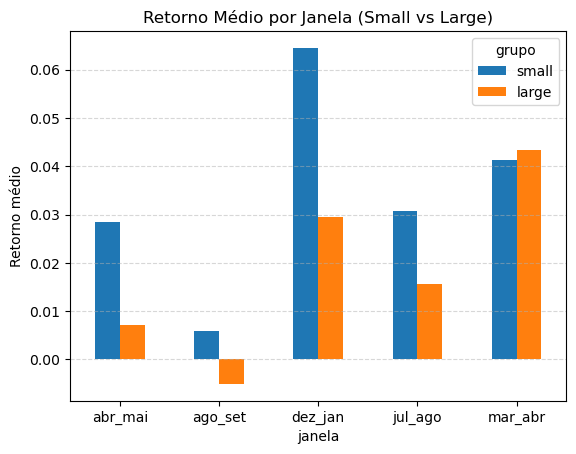

Gráfico salvo em: resultados\graficos\boxplot_spread_janelas.png


<Figure size 1000x500 with 0 Axes>

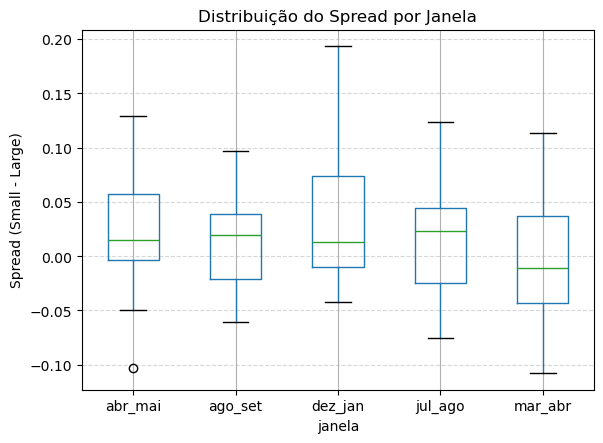

Gráfico salvo em: resultados\graficos\linha_spread_tempo.png


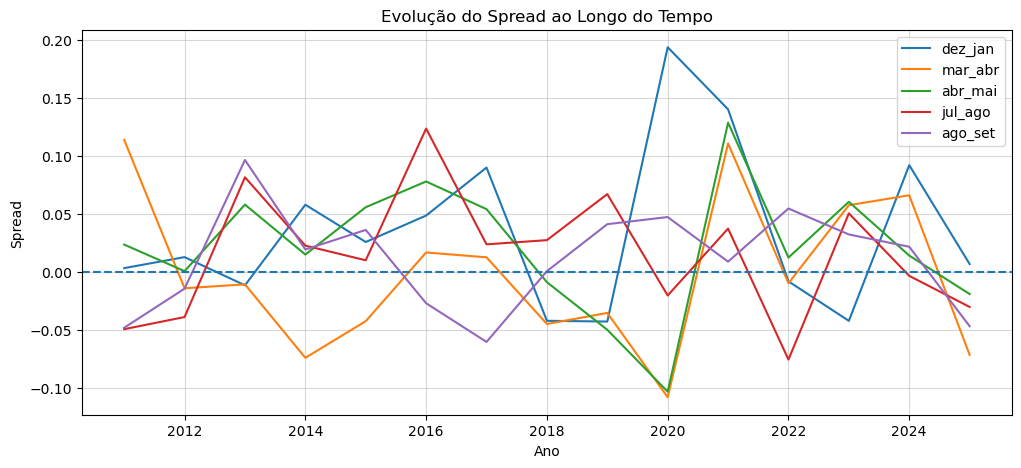

Gráfico salvo em: resultados\graficos\hist_spread_janeiro.png


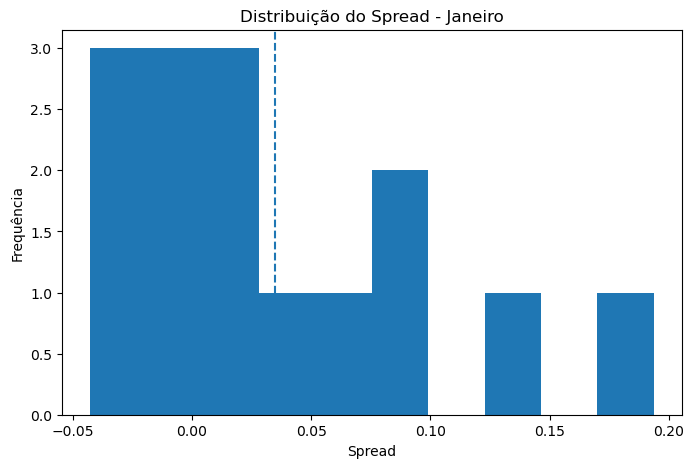

GRÁFICOS GERADOS COM SUCESSO


In [13]:
# ==========================================================
# ETAPA 6 - GRÁFICOS
# ==========================================================

print("=" * 70)
print("GERANDO GRÁFICOS")
print("=" * 70)

df = df_janelas_resumo.copy()

# ----------------------------------------------------------
# 1) GRÁFICO - RETORNO MÉDIO POR JANELA
# ----------------------------------------------------------
plt.figure(figsize=(10, 5))

tabela_plot = df.groupby("janela")[["small", "large"]].mean()

tabela_plot.plot(kind="bar")

plt.title("Retorno Médio por Janela (Small vs Large)")
plt.ylabel("Retorno médio")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)

salvar_grafico("grafico_retorno_medio_janelas.png")
plt.show()

# ----------------------------------------------------------
# 2) BOXPLOT DO SPREAD
# ----------------------------------------------------------
plt.figure(figsize=(10, 5))

df.boxplot(column="spread_small_minus_large", by="janela")

plt.title("Distribuição do Spread por Janela")
plt.suptitle("")
plt.ylabel("Spread (Small - Large)")
plt.grid(axis="y", linestyle="--", alpha=0.5)

salvar_grafico("boxplot_spread_janelas.png")
plt.show()

# ----------------------------------------------------------
# 3) LINHA TEMPORAL DO SPREAD
# ----------------------------------------------------------
plt.figure(figsize=(12, 5))

for janela in df["janela"].unique():
    df_temp = df[df["janela"] == janela]
    plt.plot(df_temp["ano"], df_temp["spread_small_minus_large"], label=janela)

plt.axhline(0, linestyle="--")
plt.title("Evolução do Spread ao Longo do Tempo")
plt.xlabel("Ano")
plt.ylabel("Spread")
plt.legend()
plt.grid(alpha=0.5)

salvar_grafico("linha_spread_tempo.png")
plt.show()

# ----------------------------------------------------------
# 4) HISTOGRAMA DO SPREAD (JANEIRO)
# ----------------------------------------------------------
plt.figure(figsize=(8, 5))

dados_jan = df[df["janela"] == "dez_jan"]["spread_small_minus_large"]

plt.hist(dados_jan, bins=10)

plt.axvline(dados_jan.mean(), linestyle="--")
plt.title("Distribuição do Spread - Janeiro")
plt.xlabel("Spread")
plt.ylabel("Frequência")

salvar_grafico("hist_spread_janeiro.png")
plt.show()

print("=" * 70)
print("GRÁFICOS GERADOS COM SUCESSO")
print("=" * 70)

# HTML Final

In [14]:
# ==========================================================
# HTML FINAL - EFEITO JANEIRO NO BRASIL
# ==========================================================
# =============================
# CAMINHOS
# =============================
BASE_DIR = Path.cwd()

RESULTADOS_DIR = BASE_DIR / "resultados"
GRAFICOS_DIR = RESULTADOS_DIR / "graficos"
TABELAS_DIR = RESULTADOS_DIR / "tabelas"

if not GRAFICOS_DIR.exists():
    GRAFICOS_DIR = RESULTADOS_DIR

if not TABELAS_DIR.exists():
    TABELAS_DIR = RESULTADOS_DIR

# =============================
# FUNÇÕES AUXILIARES
# =============================
def arquivo_existe(pasta, nome, extensao):
    return (pasta / f"{nome}.{extensao}").exists()


def ler_html_tabela(nome_arquivo):
    caminho = TABELAS_DIR / f"{nome_arquivo}.html"
    if caminho.exists():
        with open(caminho, "r", encoding="utf-8") as f:
            return f.read()
    return ""


def imagem_html(nome_arquivo, titulo=None):
    caminho = GRAFICOS_DIR / f"{nome_arquivo}.png"
    if not caminho.exists():
        return ""

    caminho_rel = caminho.relative_to(BASE_DIR).as_posix()
    titulo_html = f"<h3>{html.escape(titulo)}</h3>" if titulo else ""

    return f"""
    <div class="chart-card">
        {titulo_html}
        <img src="{caminho_rel}" alt="{html.escape(nome_arquivo)}" class="zoomable-img">
    </div>
    """

def bloco_duplo_imagens(imagens):
    html_imgs = "".join([
        imagem_html(nome, titulo)
        for nome, titulo in imagens
        if arquivo_existe(GRAFICOS_DIR, nome, "png")
    ])
    if not html_imgs:
        return ""
    return f'<div class="grid-2">{html_imgs}</div>'

def bloco_tabelas_html(tabelas):
    html_tabs = ""

    for nome, titulo in tabelas:
        tabela_html = ler_html_tabela(nome)

        if tabela_html.strip():
            html_tabs += f"""
            <div class="table-block">
                <h3>{html.escape(titulo)}</h3>
                <div class="table-wrapper">
                    {tabela_html}
                </div>
            </div>
            """

    return html_tabs

def secao_html(titulo, descricao="", conteudo=""):
    if not conteudo.strip():
        return ""
    descricao_html = f"<p class='section-desc'>{html.escape(descricao)}</p>" if descricao else ""
    return f"""
    <section class="section">
        <h2>{html.escape(titulo)}</h2>
        {descricao_html}
        {conteudo}
    </section>
    """
    
# =============================
# CONTEÚDO DAS SEÇÕES
# =============================

# ----------------------------------------------------------
# 0) RESUMO EXECUTIVO
# ----------------------------------------------------------
conteudo_resumo = """
<section class="executive-summary">
    <div class="exec-main">
        <h2>Resumo Executivo</h2>
        <p>
            Este projeto investiga a existência do <b>efeito janeiro</b> no mercado acionário brasileiro,
            comparando o desempenho de ações de menor e maior liquidez.
        </p>
        <p>
            A análise utiliza a liquidez como proxy de tamanho e avalia se ações menos líquidas
            apresentam desempenho superior na janela de dezembro→janeiro em relação a outras janelas do ano.
        </p>

        <div class="highlight-grid">
            <div class="highlight-card">
                <span class="label">Pergunta central</span>
                <div class="value">Existe efeito janeiro no Brasil?</div>
            </div>
            <div class="highlight-card">
                <span class="label">Proxy</span>
                <div class="value">Liquidez média de novembro</div>
            </div>
            <div class="highlight-card">
                <span class="label">Comparação</span>
                <div class="value">Bottom 30% vs Top 30%</div>
            </div>
            <div class="highlight-card">
                <span class="label">Métodos</span>
                <div class="value">Testes estatísticos + análise temporal</div>
            </div>
        </div>
    </div>

    <div class="exec-side">
        <h2>Key Takeaways</h2>
        <div class="takeaways">
            <div class="takeaway-card">
                <h3>Evidência econômica consistente</h3>
                <p>O spread médio em dezembro→janeiro foi o maior entre as janelas analisadas.</p>
            </div>
            <div class="takeaway-card">
                <h3>Evidência estatística moderada</h3>
                <p>O efeito foi significativo, mas próximo ao limite de 5%, indicando robustez limitada.</p>
            </div>
            <div class="takeaway-card">
                <h3>Sensibilidade a eventos extremos</h3>
                <p>O gráfico mostra que 2020 teve impacto relevante no resultado, elevando o spread médio.</p>
            </div>
            <div class="takeaway-card">
                <h3>Efeito não totalmente estável</h3>
                <p>Outras janelas também apresentam spreads positivos, embora menos consistentes.</p>
            </div>
        </div>
    </div>
</section>
"""

# ----------------------------------------------------------
# 1) INTRODUÇÃO
# ----------------------------------------------------------
conteudo_introducao = """
<div class="texto-livre">
    <p>
        O chamado <b>efeito janeiro</b> é uma das anomalias sazonais mais conhecidas da literatura financeira.
        Em termos gerais, a hipótese sugere que ações menores ou menos negociadas tendem a apresentar
        desempenho relativamente superior no início do ano.
    </p>

    <p>
        Como a base histórica não dispõe de market cap confiável para todo o período, este estudo utiliza
        a <b>liquidez média de novembro</b> como proxy de tamanho, classificando os ativos em grupos de
        menor e maior liquidez antes da janela analisada.
    </p>

    <p>
        O estudo compara o retorno das carteiras formadas com o <b>bottom 30%</b> e o <b>top 30%</b>
        da distribuição de liquidez, observando a janela principal de dezembro→janeiro e também outras
        janelas de controle ao longo do ano.
    </p>
</div>
"""

# ----------------------------------------------------------
# 2) METODOLOGIA
# ----------------------------------------------------------
conteudo_metodologia = """
<div class="texto-livre">
    <p>
        A base foi preparada com dados históricos por ticker, contendo data, preço ajustado
        (<b>close_adj</b>) e volume financeiro (<b>volume_fin</b>).
    </p>

    <p>
        Para cada ano da amostra, foi calculada a liquidez média de novembro, utilizada como critério
        de classificação dos ativos.
    </p>

    <ul>
        <li><b>Small caps proxy:</b> bottom 30% em liquidez</li>
        <li><b>Large caps proxy:</b> top 30% em liquidez</li>
        <li><b>40% centrais:</b> excluídos para aumentar o contraste</li>
    </ul>

    <p>
        A janela principal foi definida como:
    </p>

    <ul>
        <li><b>Entrada:</b> primeiro pregão após 15 de dezembro</li>
        <li><b>Saída:</b> último pregão útil de janeiro</li>
    </ul>

    <p>
        Além da janela principal, também foram testadas janelas de controle, como março→abril,
        abril→maio, julho→agosto e agosto→setembro.
    </p>

    <p>
        Na etapa estatística, foram utilizados:
    </p>

    <ul>
        <li><b>Teste t unilateral</b> para verificar se o spread médio é maior que zero</li>
        <li><b>Teste de permutação</b> para robustez empírica</li>
        <li><b>Estatísticas descritivas</b> para medir consistência do efeito ao longo dos anos</li>
    </ul>

    <p>
        Os retornos foram calculados com base em <b>preços ajustados</b>, buscando refletir melhor o
        retorno econômico total dos ativos.
    </p>
</div>
"""

# ----------------------------------------------------------
# 3) TABELAS
# ----------------------------------------------------------
conteudo_tabelas = bloco_tabelas_html([
    ("tabela_amostra_anual", "Amostra Anual de Ativos Elegíveis"),
    ("tabela_retorno_carteiras", "Retornos das Carteiras na Janela Principal"),
    ("tabela_base_consolidada_janelas", "Base Consolidada das Janelas"),
    ("tabela_comparacao_janelas", "Comparação entre Janelas"),
    ("tabela_resumo_estatistico", "Resumo Estatístico dos Spreads"),
    ("tabela_testes_estatisticos", "Testes Estatísticos"),
])

# ----------------------------------------------------------
# 4) GRÁFICOS
# ----------------------------------------------------------
conteudo_graficos = (
    bloco_duplo_imagens([
        ("grafico_retorno_medio_janelas", "Retorno Médio por Janela: Small vs Large"),
        ("boxplot_spread_janelas", "Distribuição do Spread por Janela"),
    ])
    +
    bloco_duplo_imagens([
        ("linha_spread_tempo", "Evolução Temporal do Spread"),
        ("hist_spread_janeiro", "Distribuição do Spread em Dezembro→Janeiro"),
    ])
)

# ----------------------------------------------------------
# 5) LEITURA DOS RESULTADOS
# ----------------------------------------------------------
conteudo_resultados = """
<div class="texto-livre">
    <p>
        A análise indica que a janela de <b>dezembro→janeiro</b> apresenta o maior spread médio entre
        ações de menor e maior liquidez dentre todas as janelas avaliadas, sugerindo a presença de um
        possível efeito janeiro no mercado brasileiro.
    </p>

    <p>
        Do ponto de vista estatístico, o efeito apresentou significância próxima ao nível de 5%,
        tanto no teste t quanto no teste de permutação, indicando que dificilmente o resultado ocorre
        puramente ao acaso. No entanto, a evidência não é extremamente forte, estando próxima do limite
        convencional de significância.
    </p>

    <p>
        A análise temporal do spread revela um ponto importante: o ano de <b>2020</b> apresenta um valor
        significativamente superior aos demais, funcionando como um outlier positivo na série. Esse valor
        corresponde à janela entre <b>dezembro de 2019 e janeiro de 2020</b>, ou seja, anterior ao período
        mais crítico da pandemia de COVID-19.
    </p>

    <p>
        Portanto, o comportamento observado não está diretamente associado ao choque de mercado causado
        pela pandemia, mas possivelmente a fatores como dinâmica de liquidez, fluxo de capital e
        rebalanceamento de portfólio típicos do final e início do ano.
    </p>

    <p>
        Ainda assim, a presença desse valor elevado indica que parte da magnitude do efeito pode ser
        influenciada por eventos específicos, e não exclusivamente por um padrão estrutural estável
        ao longo do tempo.
    </p>

    <p>
        Mesmo considerando essa sensibilidade, o spread permanece majoritariamente positivo ao longo dos anos,
        indicando a existência de um padrão econômico consistente, embora com variabilidade relevante.
    </p>
</div>
"""

# ----------------------------------------------------------
# 6) CONCLUSÃO
# ----------------------------------------------------------
conteudo_conclusao = """
<div class="conclusao">
    <h2>Conclusão</h2>

    <p>
        Este projeto mostrou que ações de menor liquidez tendem a apresentar desempenho superior às de maior liquidez
        na janela entre meados de dezembro e o final de janeiro no mercado brasileiro.
    </p>

    <p>
        A diferença observada foi economicamente relevante e consistente ao longo da amostra, com o maior spread médio
        entre todas as janelas analisadas, o que está alinhado com a hipótese do efeito janeiro.
    </p>

    <p>
        No entanto, os testes estatísticos aplicados — incluindo teste t e teste de permutação — indicaram que essa
        diferença apresenta significância estatística moderada, próxima ao nível de 5%. Ou seja, embora exista um sinal
        consistente nos dados, a evidência não é suficientemente forte para afirmar com alta confiança que o efeito é
        totalmente robusto e estável ao longo do tempo.
    </p>

    <p>
        A análise temporal do spread revela um ponto importante: o ano de <b>2020</b> apresenta um valor significativamente
        superior aos demais, funcionando como um outlier positivo na série. Esse valor corresponde à janela entre
        dezembro de 2019 e janeiro de 2020, ou seja, anterior ao período mais crítico da pandemia de COVID-19.
    </p>

    <p>
        Isso indica que o comportamento observado não está diretamente associado ao choque de mercado causado pela
        pandemia, mas possivelmente a dinâmicas de liquidez, fluxo de capital e rebalanceamento de portfólio típicas do
        final e início do ano. Ainda assim, a presença desse valor elevado sugere que parte da magnitude do efeito pode
        ser influenciada por eventos específicos, e não exclusivamente por um padrão estrutural estável.
    </p>

    <p>
        Dessa forma, o efeito janeiro no Brasil deve ser interpretado como uma <b>evidência econômica plausível,
        porém com robustez estatística moderada</b>, e não como uma anomalia forte e estável ao longo do tempo.
    </p>

    <h3>Principais aprendizados</h3>
    <ul>
        <li>Janeiro apresentou o maior spread médio entre as janelas analisadas.</li>
        <li>O efeito possui suporte estatístico, mas próximo ao limite de significância.</li>
        <li>O ano de 2020 (dez/2019 → jan/2020) teve impacto relevante nos resultados.</li>
        <li>O efeito não está diretamente ligado ao período mais agudo da pandemia.</li>
        <li>Há consistência econômica, mas não total robustez estatística.</li>
        <li>O comportamento pode depender de condições específicas de mercado.</li>
    </ul>
</div>
"""

# =============================
# MONTAGEM DO HTML
# =============================
html_final = f"""
<!DOCTYPE html>
<html lang="pt-BR">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Efeito Janeiro no Brasil</title>
    <link rel="stylesheet" href="https://cdn.datatables.net/1.13.8/css/jquery.dataTables.min.css">
    <style>
        body {{
            font-family: Arial, Helvetica, sans-serif;
            background: #f7f8fa;
            color: #1f2937;
            margin: 0;
            padding: 0;
        }}

        .container {{
            width: 92%;
            max-width: 1400px;
            margin: 0 auto;
            padding: 24px 0 48px 0;
        }}

        .hero {{
            background: linear-gradient(135deg, #111827, #1f2937);
            color: white;
            padding: 32px;
            border-radius: 16px;
            margin-bottom: 28px;
            box-shadow: 0 10px 25px rgba(0,0,0,0.15);
        }}

        .hero h1 {{
            margin: 0 0 12px 0;
            font-size: 2rem;
        }}

        .hero p {{
            margin: 6px 0;
            line-height: 1.6;
        }}

        .nav {{
            display: flex;
            flex-wrap: wrap;
            gap: 10px;
            margin-top: 20px;
        }}

        .nav a {{
            text-decoration: none;
            color: white;
            background: rgba(255,255,255,0.12);
            padding: 10px 14px;
            border-radius: 10px;
            font-size: 0.95rem;
        }}

        .section {{
            background: white;
            border-radius: 16px;
            padding: 24px;
            margin-bottom: 24px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.08);
        }}

        .section h2 {{
            margin-top: 0;
            font-size: 1.5rem;
            color: #111827;
        }}

        .section-desc {{
            color: #4b5563;
            margin-bottom: 20px;
            line-height: 1.6;
        }}

        .texto-livre p,
        .conclusao p {{
            line-height: 1.8;
            color: #374151;
        }}

        .texto-livre ul,
        .conclusao ul {{
            line-height: 1.8;
            color: #374151;
            padding-left: 22px;
        }}

        .grid-2 {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(420px, 1fr));
            gap: 20px;
            margin-bottom: 20px;
        }}

        .chart-card {{
            background: #fafafa;
            border: 1px solid #e5e7eb;
            border-radius: 14px;
            padding: 16px;
        }}

        .chart-card h3 {{
            margin-top: 0;
            font-size: 1rem;
        }}

        .chart-card img {{
            width: 100%;
            border-radius: 10px;
            display: block;
            cursor: zoom-in;
            transition: transform 0.2s ease;
        }}

        .chart-card img:hover {{
            transform: scale(1.01);
        }}

        .table-block {{
            margin-top: 18px;
            margin-bottom: 18px;
        }}

        .table-block h3 {{
            margin-bottom: 10px;
        }}

        .table-wrapper {{
            overflow-x: auto;
            overflow-y: auto;
            max-height: 700px;
            border: 1px solid #e5e7eb;
            border-radius: 12px;
            background: #fff;
            padding: 8px;
        }}

        .footer {{
            text-align: center;
            color: #6b7280;
            font-size: 0.9rem;
            margin-top: 32px;
        }}

        .modal {{
            display: none;
            position: fixed;
            z-index: 9999;
            inset: 0;
            background: rgba(0, 0, 0, 0.88);
            justify-content: center;
            align-items: center;
            padding: 24px;
        }}

        .modal.show {{
            display: flex;
        }}

        .modal img {{
            max-width: 95%;
            max-height: 92vh;
            border-radius: 12px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.35);
        }}

        .modal-close {{
            position: absolute;
            top: 18px;
            right: 24px;
            color: white;
            font-size: 2rem;
            font-weight: bold;
            cursor: pointer;
            line-height: 1;
        }}

        .executive-summary {{
            display: grid;
            grid-template-columns: 1.4fr 1fr;
            gap: 20px;
            margin: 0 0 24px 0;
        }}

        .exec-main,
        .exec-side {{
            background: white;
            border-radius: 16px;
            padding: 24px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.08);
        }}

        .exec-main h2,
        .exec-side h2 {{
            margin-top: 0;
            color: #111827;
        }}

        .exec-main p,
        .exec-side p {{
            color: #4b5563;
            line-height: 1.7;
        }}

        .highlight-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
            gap: 16px;
            margin-top: 18px;
        }}

        .highlight-card {{
            background: #f9fafb;
            border: 1px solid #e5e7eb;
            border-radius: 14px;
            padding: 16px;
        }}

        .highlight-card .label {{
            display: block;
            font-size: 0.85rem;
            color: #6b7280;
            margin-bottom: 8px;
        }}

        .highlight-card .value {{
            font-size: 1.05rem;
            font-weight: bold;
            color: #111827;
            line-height: 1.4;
        }}

        .takeaways {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(260px, 1fr));
            gap: 16px;
            margin-top: 18px;
        }}

        .takeaway-card {{
            background: #111827;
            color: white;
            border-radius: 14px;
            padding: 18px;
            box-shadow: 0 6px 18px rgba(0,0,0,0.10);
        }}

        .takeaway-card h3 {{
            margin-top: 0;
            margin-bottom: 10px;
            font-size: 1rem;
        }}

        .takeaway-card p {{
            margin: 0;
            line-height: 1.6;
            color: rgba(255,255,255,0.88);
        }}

        @media (max-width: 900px) {{
            .executive-summary {{
                grid-template-columns: 1fr;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">

        <div class="hero">
            <h1>Efeito Janeiro no Brasil</h1>
            <p>Uma análise empírica do desempenho relativo entre small caps proxy e large caps proxy no mercado acionário brasileiro.</p>
            <p>O estudo utiliza liquidez como proxy de tamanho, compara a janela dezembro→janeiro com janelas de controle e combina evidência econômica, estatística e visual.</p>

            <div class="nav">
                <a href="#introducao">Introdução</a>
                <a href="#metodologia">Metodologia</a>
                <a href="#tabelas">Tabelas</a>
                <a href="#graficos">Gráficos</a>
                <a href="#resultados">Resultados</a>
                <a href="#conclusao">Conclusão</a>
            </div>
        </div>

        {conteudo_resumo}

        <div id="introducao">
            {secao_html("Introdução", "Contexto do efeito janeiro, proxy utilizada e objetivo da análise.", conteudo_introducao)}
        </div>

        <div id="metodologia">
            {secao_html("Metodologia", "Construção das carteiras, definição das janelas e testes utilizados.", conteudo_metodologia)}
        </div>

        <div id="tabelas">
            {secao_html("Tabelas", "Saídas principais do projeto com filtro, ordenação e scroll.", conteudo_tabelas)}
        </div>

        <div id="graficos">
            {secao_html("Gráficos", "Visualizações principais do comportamento do spread small minus large.", conteudo_graficos)}
        </div>

        <div id="resultados">
            {secao_html("Leitura dos Resultados", "Interpretação econômica e estatística dos achados do estudo.", conteudo_resultados)}
        </div>

        <div id="conclusao">
            {conteudo_conclusao}
        </div>

        <div class="footer">
            <p>HTML gerado automaticamente a partir dos outputs do projeto.</p>
        </div>
    </div>

    <div id="imgModal" class="modal">
        <span class="modal-close" id="modalClose">&times;</span>
        <img id="modalImg" src="" alt="Imagem ampliada">
    </div>

    <script>
        const modal = document.getElementById("imgModal");
        const modalImg = document.getElementById("modalImg");
        const modalClose = document.getElementById("modalClose");

        document.querySelectorAll(".zoomable-img").forEach(img => {{
            img.addEventListener("click", () => {{
                modalImg.src = img.src;
                modalImg.alt = img.alt;
                modal.classList.add("show");
            }});
        }});

        modalClose.addEventListener("click", () => {{
            modal.classList.remove("show");
            modalImg.src = "";
        }});

        modal.addEventListener("click", (e) => {{
            if (e.target === modal) {{
                modal.classList.remove("show");
                modalImg.src = "";
            }}
        }});

        document.addEventListener("keydown", (e) => {{
            if (e.key === "Escape") {{
                modal.classList.remove("show");
                modalImg.src = "";
            }}
        }});
    </script>

    <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>
    <script src="https://cdn.datatables.net/1.13.8/js/jquery.dataTables.min.js"></script>

    <script>
        $(document).ready(function () {{
            $("table").DataTable({{
                paging: false,
                info: true,
                searching: true,
                ordering: true,
                lengthChange: false,
                order: [],
                language: {{
                    decimal: ",",
                    thousands: ".",
                    zeroRecords: "Nenhum registro encontrado",
                    info: "Mostrando _TOTAL_ registros",
                    infoEmpty: "Mostrando 0 registros",
                    infoFiltered: "(filtrado de _MAX_ registros no total)",
                    search: "Filtrar:",
                    paginate: {{
                        first: "Primeiro",
                        last: "Último",
                        next: "Próximo",
                        previous: "Anterior"
                    }}
                }}
            }});
        }});
    </script>
</body>
</html>
"""

# =============================
# SALVAR HTML
# =============================
HTML_PATH = "index.html"

with open(HTML_PATH, "w", encoding="utf-8") as f:
    f.write(html_final)

print(f"HTML salvo em: {HTML_PATH}")

HTML salvo em: index.html


# Conclusão

Este projeto mostrou que ações de menor liquidez tendem a apresentar desempenho superior às de maior liquidez na janela entre meados de dezembro e o final de janeiro no mercado brasileiro.

A diferença observada foi economicamente relevante e consistente ao longo da amostra, com o maior spread médio entre todas as janelas analisadas, o que está alinhado com a hipótese do chamado efeito janeiro.

No entanto, os testes estatísticos aplicados — incluindo teste t e teste de permutação — indicaram que essa diferença apresenta significância estatística moderada, próxima ao nível de 5%.

Ou seja, embora exista um sinal consistente nos dados, a evidência não é suficientemente forte para afirmar com alta confiança que o efeito é totalmente robusto e estável ao longo do tempo.

📊 Interpretação dos Resultados

Apesar da evidência estatística moderada, alguns pontos reforçam a relevância econômica do achado:

A janela dezembro→janeiro apresentou o maior spread médio entre todas as janelas analisadas
A maioria dos anos apresentou spread positivo, indicando consistência ao longo do tempo
Os gráficos mostram uma diferença visual clara entre janeiro e as demais janelas
O efeito permanece positivo mesmo fora de anos extremos

Por outro lado, a análise temporal revela um ponto importante:

O ano de 2020 (dez/2019 → jan/2020) apresenta um valor significativamente superior aos demais, funcionando como um outlier positivo
Esse comportamento não está diretamente ligado ao crash da pandemia, mas pode refletir dinâmicas de liquidez, fluxo e rebalanceamento de fim/início de ano

Esses elementos sugerem que a hipótese econômica faz sentido, mas parte da magnitude do efeito pode ser influenciada por eventos específicos, reduzindo sua robustez estatística.

🧠 Principais Aprendizados

Existe diferença econômica consistente entre ações de menor e maior liquidez
O efeito janeiro apresentou o maior spread médio entre as janelas analisadas
A significância estatística é moderada, próxima ao limite de 5%
O resultado é sensível a outliers, especialmente o ano de 2020
Outras janelas também apresentam spreads positivos, mas menos consistentes
A liquidez se mostrou uma proxy prática e funcional para segmentação de ativos

🏁 Conclusão Final

O estudo reforça uma ideia importante:

Ações menos líquidas podem, sim, apresentar desempenho superior no início do ano —
mas esse comportamento não é totalmente estável nem estatisticamente robusto em todos os períodos.